<a href="https://colab.research.google.com/github/Saisneha0209/Machine-Learning/blob/main/ETF_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.metrics import accuracy_score
import numpy as np
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('yxi.us.csv')
print(df)

            Date   Open   High    Low    Close  Volume  OpenInt
0     2010-03-18  49.28  49.53  49.28  49.4900    4200        0
1     2010-03-19  49.38  49.93  49.38  49.8900     700        0
2     2010-03-22  49.72  49.72  49.72  49.7200    1400        0
3     2010-03-23  50.00  50.00  50.00  50.0000     200        0
4     2010-03-24  50.18  50.56  50.18  50.2100   20705        0
...          ...    ...    ...    ...      ...     ...      ...
1827  2017-11-03  19.74  19.74  19.74  19.7400     190        0
1828  2017-11-06  19.69  19.69  19.64  19.6500    1469        0
1829  2017-11-07  19.45  19.54  19.45  19.5400    1904        0
1830  2017-11-09  19.36  19.58  19.36  19.4900    2041        0
1831  2017-11-10  19.42  19.42  19.40  19.4092    1431        0

[1832 rows x 7 columns]


In [2]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
x = df[["Open", "High", "Low", "Volume", "Year", "Month", "Day"]]
y = df["Close"]

print(x)
print(y)

       Open   High    Low  Volume  Year  Month  Day
0     49.28  49.53  49.28    4200  2010      3   18
1     49.38  49.93  49.38     700  2010      3   19
2     49.72  49.72  49.72    1400  2010      3   22
3     50.00  50.00  50.00     200  2010      3   23
4     50.18  50.56  50.18   20705  2010      3   24
...     ...    ...    ...     ...   ...    ...  ...
1827  19.74  19.74  19.74     190  2017     11    3
1828  19.69  19.69  19.64    1469  2017     11    6
1829  19.45  19.54  19.45    1904  2017     11    7
1830  19.36  19.58  19.36    2041  2017     11    9
1831  19.42  19.42  19.40    1431  2017     11   10

[1832 rows x 7 columns]
0       49.4900
1       49.8900
2       49.7200
3       50.0000
4       50.2100
         ...   
1827    19.7400
1828    19.6500
1829    19.5400
1830    19.4900
1831    19.4092
Name: Close, Length: 1832, dtype: float64


#LINEAR REGRESSION


In [7]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state = 42)
model = LinearRegression()
model.fit(x_train,y_train)
pred = model.predict(x_test)
user_input=np.array([[48.46,48.46,48.24,3880 , 2010, 3, 31]])
u_pred = model.predict(user_input)
print("Soo the closing price is:",u_pred)

Soo the closing price is: [48.32412079]


In [8]:
r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
print(f"R2 Score: {r2}")
print(f"Root Mean Squared Error: {rmse}")

R2 Score: 0.9994338817292461
Root Mean Squared Error: 0.2039828856282174


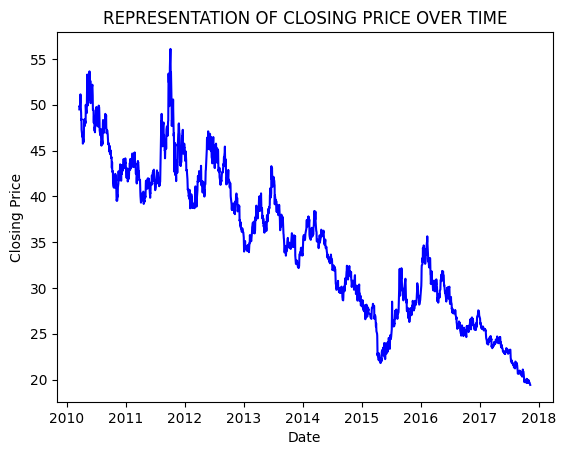

In [9]:
import matplotlib.pyplot as plt
plt.plot(df['Date'], df['Close'], color='blue', label='Actual Close')
plt.title("REPRESENTATION OF CLOSING PRICE OVER TIME")
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.show()

#High vs. Low Price

In [10]:
df['Daily_Price'] = df['High'] - df['Low']
avg_price_per_year = df.groupby('Year')['Daily_Price'].mean()
print("Average Daily Price by Year:", avg_price_per_year)

Average Daily Price by Year: Year
2010    0.411818
2011    0.563673
2012    0.356382
2013    0.315442
2014    0.249319
2015    0.385829
2016    0.283196
2017    0.087168
Name: Daily_Price, dtype: float64


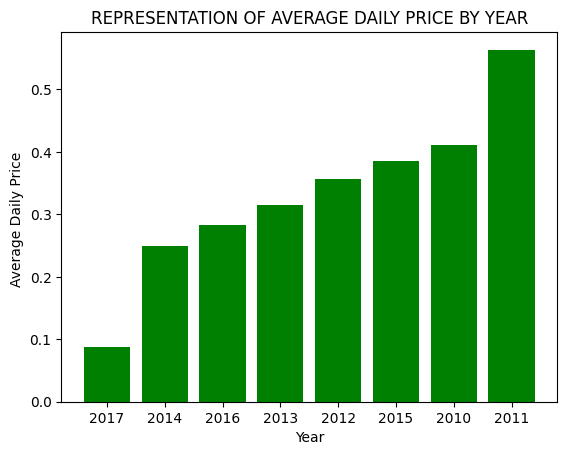

In [12]:
avg_price_per_year = avg_price_per_year.sort_values()

plt.bar(avg_price_per_year.index.astype(str) , avg_price_per_year, color='green', label='Avg Daily Price')
plt.title("REPRESENTATION OF AVERAGE DAILY PRICE BY YEAR")
plt.xlabel('Year')
plt.ylabel('Average Daily Price ')
plt.show()

In [13]:
max_volume_per_year = df.groupby('Year')['Volume'].max()
print("Maximum Volume by Year:")
print(max_volume_per_year)

Maximum Volume by Year:
Year
2010     55931
2011    110475
2012     68785
2013     38638
2014    950902
2015    242100
2016    122578
2017     33813
Name: Volume, dtype: int64


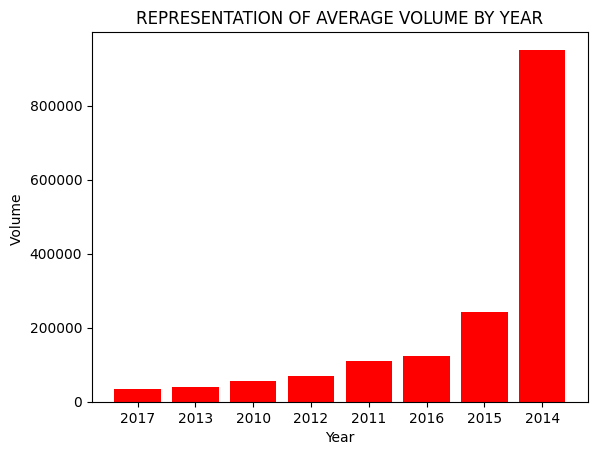

In [17]:
max_volume_per_year = max_volume_per_year.sort_values()

plt.bar(max_volume_per_year.index.astype(str) , max_volume_per_year, color='red', label='Max Volume Per Year')
plt.title("REPRESENTATION OF AVERAGE VOLUME BY YEAR")
plt.xlabel('Year')
plt.ylabel('Volume ')
plt.show()

#Logistic Regression